
📈 Model Benchmarking Results:
                     RMSE     MAE      R2
SARIMA (Baseline)  3.7263  2.9739 -0.0585
SARIMAX            3.7861  2.9080 -0.0928
Ridge              2.9569  2.4850  0.3335
Random Forest      3.7229  2.5475 -0.0566


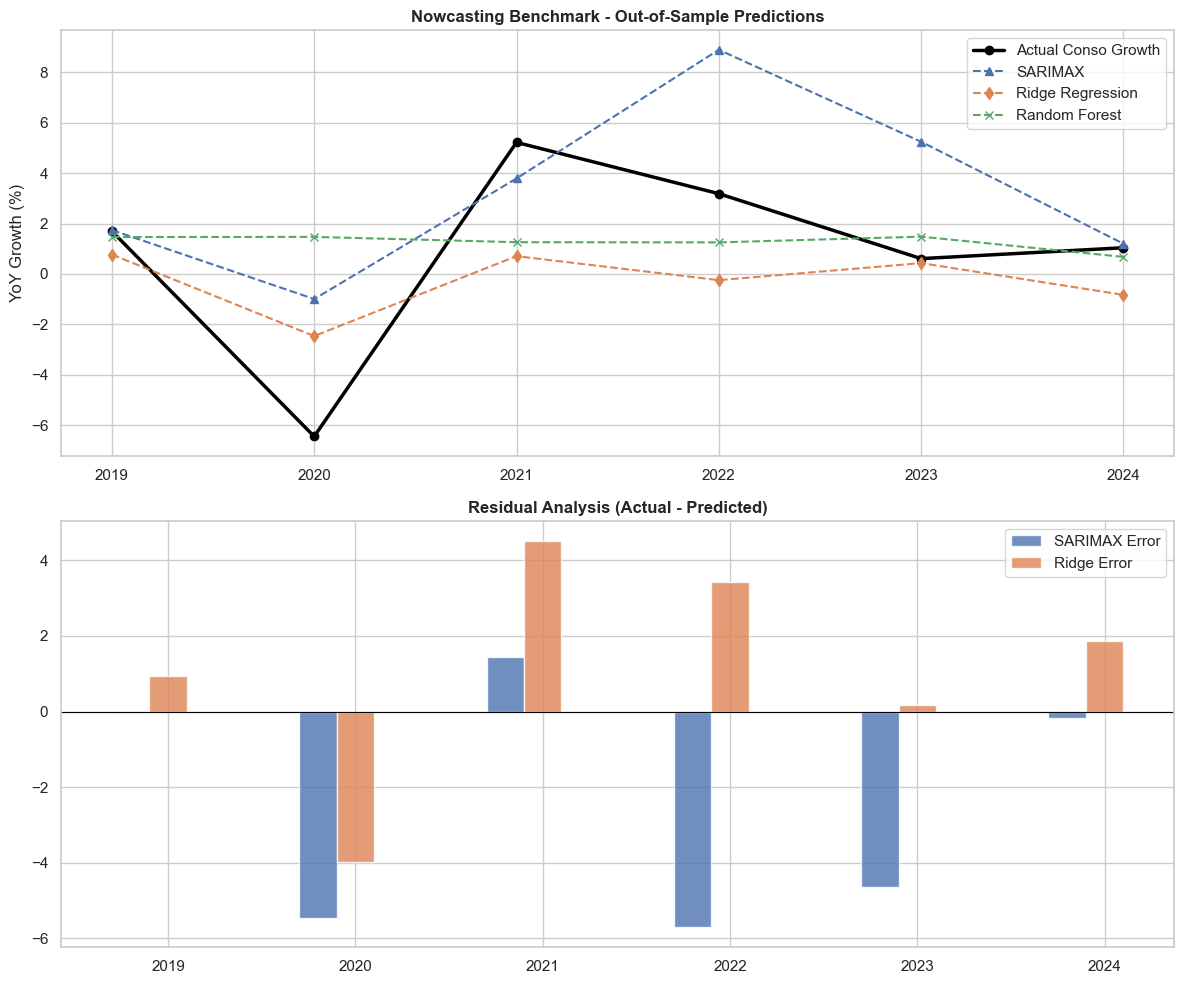

In [30]:
"""
Household Consumption Nowcasting
Author: Anas Fenniche
Date: May 2026
"""

import warnings
from typing import List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


def load_and_clean_insee(filepath: str) -> pd.DataFrame:
    """Loads and normalizes annual macroeconomic data from INSEE."""
    df_raw = pd.read_excel(filepath, sheet_name=0, header=None)

    # Parse years and clean flags like "2022 (r)"
    raw_years = df_raw.iloc[3, 1:].values
    years = []
    for y in raw_years:
        if isinstance(y, str) and '(' in y:
            years.append(int(y.split('(')[0].strip()))
        elif isinstance(y, (int, float)) and not pd.isna(y):
            years.append(int(y))
        else:
            years.append(None)

    df = pd.DataFrame({
        'year': years,
        'pib_growth': df_raw.iloc[5, 1:len(years)+1].values,
        'conso_growth': df_raw.iloc[10, 1:len(years)+1].values
    }).dropna(subset=['year'])

    df['year'] = df['year'].astype(int)
    for col in ['pib_growth', 'conso_growth']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    return df.dropna().reset_index(drop=True)


def load_and_clean_trends(filepath: str) -> pd.DataFrame:
    """Loads Google Trends syncs and aggregates on an annual basis."""
    df = pd.read_csv(filepath)
    df.columns = [
        'date', 'soldes', 'black_friday', 'credit_conso', 
        'electromenager', 'credit_immobilier', 'amazon', 'chomage', 'inflation'
    ]
    
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    
    # Drop features with structural breaks / high sparsity before 2010
    df = df.drop(columns=['amazon', 'black_friday'])
    
    # Simple annual average aggregation to match macroeconomic frequency
    features = ['soldes', 'credit_conso', 'electromenager', 'credit_immobilier', 'chomage', 'inflation']
    return df.groupby('year')[features].mean().reset_index()


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Helper to return standard regression metrics."""
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


def run_pipeline():
    # 1. Data Pipeline
    df_insee = load_and_clean_insee('econ-gen-pib-composante.xlsx')
    df_trends = load_and_clean_trends('time_series_FR_20040101-0000_20260515-2211.csv')
    
    df = df_insee.merge(df_trends, on='year', how='inner')
    df.to_csv('data_final.csv', index=False)
    
    features = ['soldes', 'credit_conso', 'electromenager', 'credit_immobilier', 'chomage', 'inflation']
    target = 'conso_growth'
    
    # 2. Train/Test Split (Time-series specific)
    train_size = int(len(df) * 0.75)
    train, test = df.iloc[:train_size], df.iloc[train_size:]
    
    results = {}
    predictions = {'actual': test[target].values, 'year': test['year'].values}

    # Model 1: SARIMA (Baseline without exogenous features)
    try:
        model_sarima = SARIMAX(train[target], order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
        res_sarima = model_sarima.fit(disp=False)
        predictions['sarima'] = res_sarima.forecast(steps=len(test)).values
        results['SARIMA (Baseline)'] = compute_metrics(predictions['actual'], predictions['sarima'])
    except Exception as e:
        print(f"SARIMA failure: {e}")

    # Model 2: SARIMAX (With alternative data)
    try:
        model_sarimax = SARIMAX(train[target], exog=train[features], order=(1, 0, 1))
        res_sarimax = model_sarimax.fit(disp=False)
        predictions['sarimax'] = res_sarimax.forecast(steps=len(test), exog=test[features]).values
        results['SARIMAX'] = compute_metrics(predictions['actual'], predictions['sarimax'])
    except Exception as e:
        print(f"SARIMAX failure: {e}")

    # Feature Scaling for ML algorithms
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[features])
    X_test = scaler.transform(test[features])

    # Model 3: Regularized Linear Model (Ridge)
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, train[target])
    predictions['ridge'] = ridge.predict(X_test)
    results['Ridge'] = compute_metrics(predictions['actual'], predictions['ridge'])

    # Model 4: Non-linear Baseline (Random Forest)
    rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
    rf.fit(train[features], train[target])
    predictions['rf'] = rf.predict(test[features])
    results['Random Forest'] = compute_metrics(predictions['actual'], predictions['rf'])

    # 3. Evaluation & Export
    df_results = pd.DataFrame(results).T
    df_results.to_csv('model_results.csv')
    
    print("\n📈 Model Benchmarking Results:")
    print(df_results.round(4))
    
    # Plotting code adjusted to clean style
    generate_plots(test, predictions, df)


def generate_plots(test: pd.DataFrame, predictions: dict, df: pd.DataFrame):
    """Generates clean validation plots for reporting."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Forecast tracking
    ax1.plot(predictions['year'], predictions['actual'], label='Actual Conso Growth', color='black', lw=2.5, marker='o')
    if 'sarimax' in predictions:
        ax1.plot(predictions['year'], predictions['sarimax'], label='SARIMAX', linestyle='--', marker='^')
    if 'ridge' in predictions:
        ax1.plot(predictions['year'], predictions['ridge'], label='Ridge Regression', linestyle='--', marker='d')
    if 'rf' in predictions:
        ax1.plot(predictions['year'], predictions['rf'], label='Random Forest', linestyle='--', marker='x')
        
    ax1.set_title('Nowcasting Benchmark - Out-of-Sample Predictions', fontsize=12, fontweight='bold')
    ax1.set_ylabel('YoY Growth (%)')
    ax1.legend(frameon=True)
    
    # Error distribution bar chart
    x = np.arange(len(test))
    width = 0.2
    
    if 'sarimax' in predictions:
        ax2.bar(x - width, predictions['actual'] - predictions['sarimax'], width, label='SARIMAX Error', alpha=0.8)
    if 'ridge' in predictions:
        ax2.bar(x, predictions['actual'] - predictions['ridge'], width, label='Ridge Error', alpha=0.8)
        
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(predictions['year'].astype(int))
    ax2.set_title('Residual Analysis (Actual - Predicted)', fontsize=12, fontweight='bold')
    ax2.legend(frameon=True)
    
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    run_pipeline()